# Student Placement Prediction using a Decision Tree

In this notebook we build a complete machine learning project step by step.
We use simple code and explain every step in simple English.

In [1]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

---
## Step 1: Problem

**Real-life story:** A college placement cell wants to know which students are likely to get a job placement.
If they know this early, they can give extra help (mock interviews, practice tests, mentoring) to the students who need it.

**What we are predicting:** `placement_status` (Placed or Not Placed)

**Type of problem:** Classification, because the answer is one of two classes.

**What we use to predict (features):**
- Student details: gender, branch, extracurricular activities
- Habits: study hours, sleep hours, internet usage
- Performance: attendance, assignments completed, previous score, exam score

**Two types of mistakes the model can make**
- It says "Placed" but the student is not placed: the student may miss the extra help.
- It says "Not Placed" but the student is placed: the college wastes some effort.

---
## Step 2: Data + EDA (Find patterns)

EDA means **Exploratory Data Analysis**.
It is like meeting a new student for the first time: first you look, ask questions and understand, then you decide what to do.

### 2.1 Load the data

In [2]:
df_copy= pd.read_csv('student_performance_dataset.csv')
# df_copy = df.copy()
# df.head(5)
df_copy.head(5)

,student_id,gender,branch,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,extracurricular,exam_score,placement_status
0,STU01978,Female,Mechanical,1.5,68.2,6.7,2.6,15.0,63.6,Yes,60.8,Placed
1,STU03881,Male,Mechanical,5.0,80.9,5.5,6.2,12.0,55.4,No,58.8,Not Placed
2,STU00053,Female,CSE,0.8,69.4,7.4,3.6,NaN,43.2,No,44.0,Not Placed
3,STU02552,Female,Commerce,1.3,77.1,7.4,3.6,NaN,76.9,Yes,55.5,Placed
4,STU02247,Male,IT,0.0,46.8,7.4,5.6,4.0,49.7,Yes,41.6,Not Placed


### 2.2 Understand the columns

| Column | Meaning |
|---|---|
| `student_id` | Unique ID of the student (only a label, not useful for prediction) |
| `gender` | Male or Female |
| `branch` | CSE, IT, ECE, Mechanical, Civil, Commerce |
| `study_hours` | Study hours per day |
| `attendance` | Attendance in percent |
| `sleep_hours` | Sleep hours per day |
| `internet_usage` | Internet use in hours per day |
| `assignments_completed` | Number of assignments completed |
| `previous_score` | Marks in the previous exam |
| `extracurricular` | Does the student take part in extra activities? |
| `exam_score` | Latest exam marks |
| `placement_status` | **Target**: Placed or Not Placed |

In [3]:
# Data types and non-null counts
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             10000 non-null  object 
 1   gender                 10000 non-null  object 
 2   branch                 9901 non-null   object 
 3   study_hours            9699 non-null   float64
 4   attendance             9600 non-null   float64
 5   sleep_hours            9702 non-null   float64
 6   internet_usage         9696 non-null   float64
 7   assignments_completed  9751 non-null   float64
 8   previous_score         9652 non-null   float64
 9   extracurricular        10000 non-null  object 
 10  exam_score             10000 non-null  float64
 11  placement_status       10000 non-null  object 
dtypes: float64(7), object(5)
memory usage: 937.6+ KB


In [4]:
# Quick summary of the number columns
df_copy.describe()

,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score
count,9699.000000,9600.000000,9702.000000,9696.000000,9751.000000,9652.000000,10000.000000
mean,3.487277,75.787323,6.804556,4.495153,12.835812,61.782553,60.555980
std,1.630787,10.962674,1.114314,1.687334,4.129272,13.031526,14.234672
min,0.000000,33.900000,1.000000,0.200000,0.000000,20.000000,0.000000
25%,2.400000,68.400000,6.100000,3.400000,10.000000,52.800000,50.700000
50%,3.400000,75.700000,6.800000,4.500000,13.000000,61.900000,60.500000
75%,4.500000,83.400000,7.600000,5.600000,16.000000,70.700000,70.100000
max,21.300000,100.000000,14.000000,21.500000,20.000000,100.000000,100.000000


In [5]:
# How many missing values are in each column?
df_copy.isnull().sum()

student_id                 0
gender                     0
branch                    99
study_hours              301
attendance               400
sleep_hours              298
internet_usage           304
assignments_completed    249
previous_score           348
extracurricular            0
exam_score                 0
placement_status           0
dtype: int64

In [6]:
# Are there duplicate rows?
df_copy.duplicated().sum()

np.int64(50)

In [7]:
# check Columns purity
cat_col = df_copy.select_dtypes(include = 'object').columns
cat_col
print(cat_col)
for col in cat_col:
  print(df_copy[col].unique())
  print()


Index(['student_id', 'gender', 'branch', 'extracurricular',
       'placement_status'],
      dtype='object')
['STU01978' 'STU03881' 'STU00053' ... 'STU05700' 'STU00538' 'STU09413']

['Female' 'Male' 'F' 'female' 'M' 'male']

['Mechanical' 'CSE' 'Commerce' 'IT' 'Civil' 'ECE' 'it' ' CSE ' 'commerce'
 'cse' ' Commerce ' nan 'ece' 'COMMERCE' 'mechanical' ' Civil ' ' ECE '
 'CIVIL' 'MECHANICAL' ' Mechanical ' ' IT ' 'civil']

['Yes' 'No']

['Placed' 'Not Placed']



### What is wrong with this data?

Real-world data is never perfect. Here we can see:

1. **Missing values** in many columns (study hours, attendance, sleep hours, and more).
2. **Duplicate rows**, the same student appears twice.
3. **Gender is written in many ways**: `Male`, `male`, `M`, `Female`, `female`, `F`.
4. **Branch has spelling problems**: `CSE`, `cse`, ` CSE ` (with extra spaces), `MECHANICAL`, `mechanical`.
5. **Impossible values (outliers)**: check `study_hours`, `sleep_hours` and `internet_usage` in the table above.
   Nobody can study 21 hours every day!

We will fix these in Step 3 and Step 4.

### 2.3 Is our target balanced?

<Axes: xlabel='count', ylabel='placement_status'>

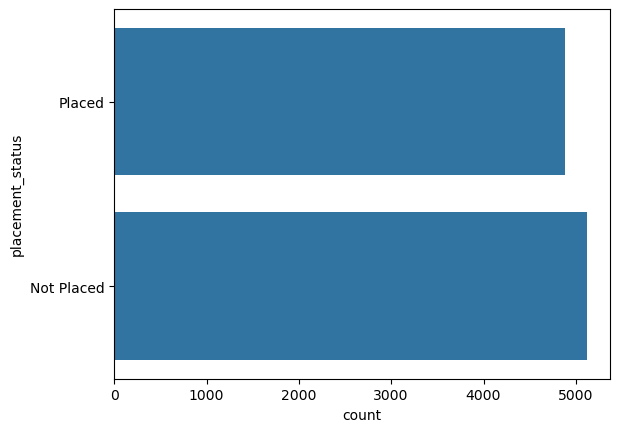

In [8]:
sns.countplot(df_copy['placement_status'])

#

### 2.4 Do placed students look different?
Let us compare the average of every number column for the two groups.

In [9]:
# Group by num_col to placement_status
num_col = df_copy.select_dtypes(include =np.number).columns
df_copy.groupby('placement_status')[num_col].mean()

,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score
placement_status,,,,,,,
Not Placed,2.890603,70.524177,6.775308,4.953032,10.478549,54.363594,51.830219
Placed,4.111519,81.249331,6.835060,4.015022,15.304430,69.512270,69.696233


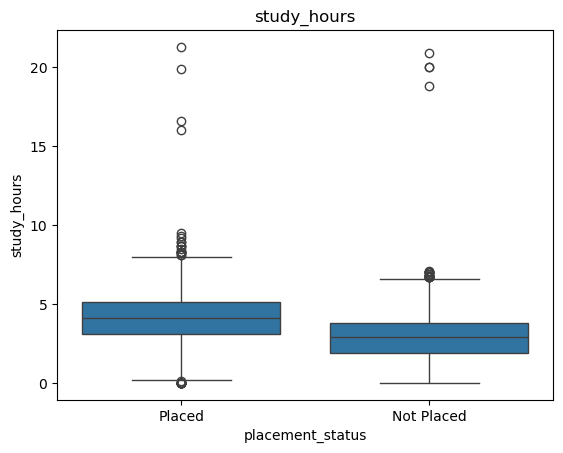

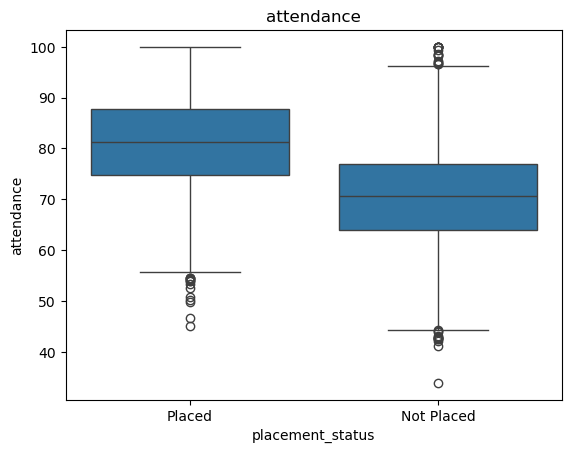

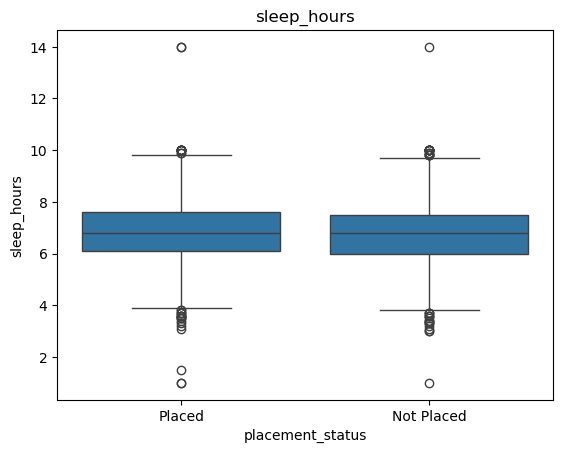

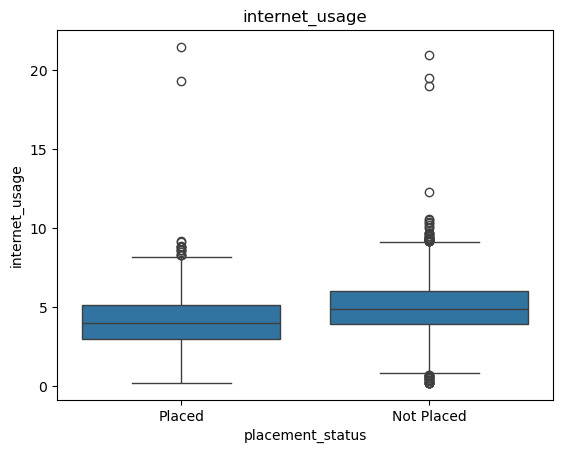

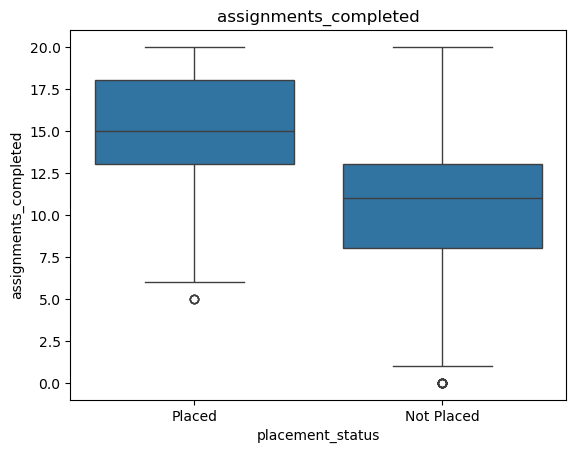

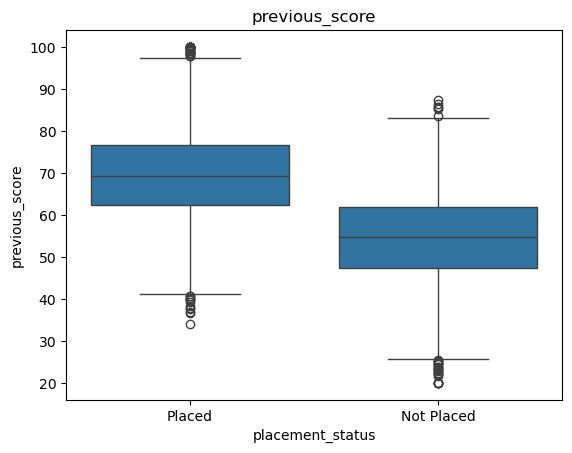

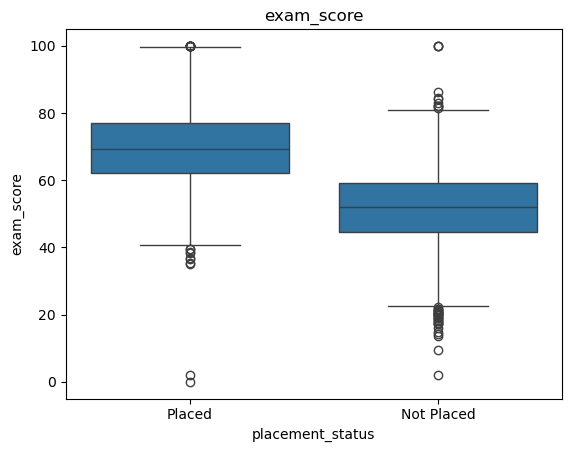

In [10]:
# Box plots: compare Placed and Not Placed for each number column
num_cols = df_copy.select_dtypes(include=np.number).columns

for col in num_cols:
    sns.boxplot(x="placement_status", y=col, data=df_copy)
    plt.title(col)
    plt.show()

<Axes: >

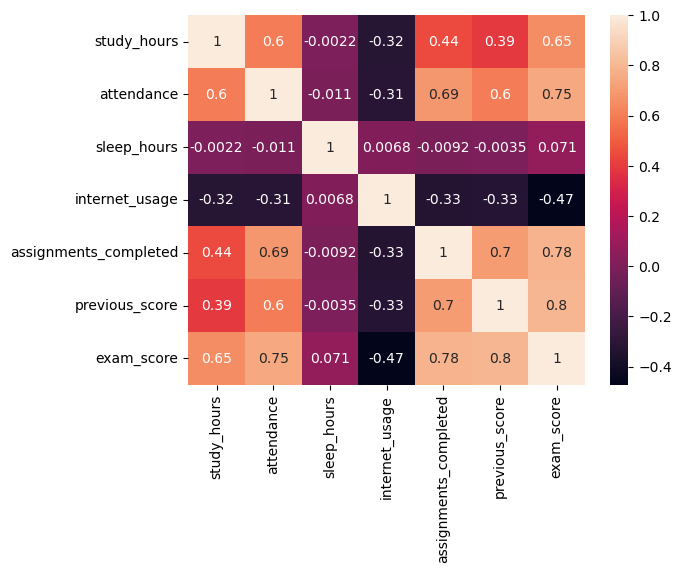

In [11]:
# Correlation: which number columns move together?
sns.heatmap(df_copy[num_col].corr(), annot = True)

---
## Step 3: Clean data

Rule: **never change the original data**. We work on a copy, so we can always go back.

We will do 5 cleaning jobs:
1. Remove duplicate rows
2. Drop `student_id` (it is only a label)
3. Fix the `gender` column
4. Fix the `branch` column
5. Fix impossible values (outliers)



In [12]:
# Make a copy so the original df stays safe

# Job 1: remove duplicate rows
df_copy.drop_duplicates(inplace = True)
df_copy.duplicated().sum()
# Job 1.0: Remove null values
df_copy.dropna(inplace=True)
df_copy.isnull().sum()

student_id               0
gender                   0
branch                   0
study_hours              0
attendance               0
sleep_hours              0
internet_usage           0
assignments_completed    0
previous_score           0
extracurricular          0
exam_score               0
placement_status         0
dtype: int64

In [13]:
# Job 2: student_id is only a label. It does not help to predict placement.
df_copy.drop(columns = ['student_id'], axis = 1, inplace = True)
df_copy.head(2)

,gender,branch,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,extracurricular,exam_score,placement_status
0,Female,Mechanical,1.5,68.2,6.7,2.6,15.0,63.6,Yes,60.8,Placed
1,Male,Mechanical,5.0,80.9,5.5,6.2,12.0,55.4,No,58.8,Not Placed


In [14]:
# Job 3: fix gender
# strip() removes extra spaces, lower() makes small letters, map() gives one clean name
df_copy['gender'] = df_copy['gender'].str.strip().str.lower().map({'male': 'male', 'female': 'female', 'm': 'male', 'f': 'female'})
df_copy['gender'].unique()

array(['female', 'male'], dtype=object)

In [15]:
# Job 4: fix branch
# Remove extra spaces and make everything CAPITAL letters, so ' cse ' becomes 'CSE'
df_copy['branch'] = df_copy['branch'].str.strip().str.upper()
df_copy['branch'].unique()

array(['MECHANICAL', 'IT', 'CSE', 'CIVIL', 'ECE', 'COMMERCE'],
      dtype=object)

In [16]:
# Job 5: fix impossible values with clip()
# clip(0, 12) means: anything above 12 becomes 12, anything below 0 becomes 0
df_copy["study_hours"] = df_copy["study_hours"].clip(0, 12)
df_copy["sleep_hours"] = df_copy["sleep_hours"].clip(3, 12)
df_copy["internet_usage"] = df_copy["internet_usage"].clip(0, 12)

df_copy[["study_hours", "sleep_hours", "internet_usage"]].describe().round(2)




,study_hours,sleep_hours,internet_usage
count,8139.00,8139.00,8139.00
mean,3.49,6.81,4.50
std,1.58,1.10,1.67
min,0.00,3.00,0.20
25%,2.40,6.10,3.40
50%,3.40,6.80,4.50
75%,4.50,7.60,5.60
max,12.00,12.00,12.00


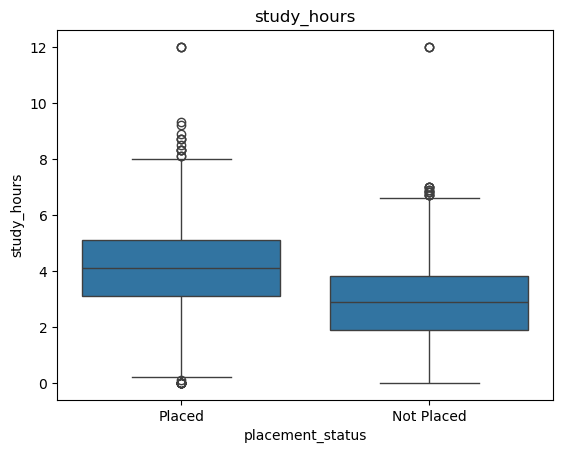

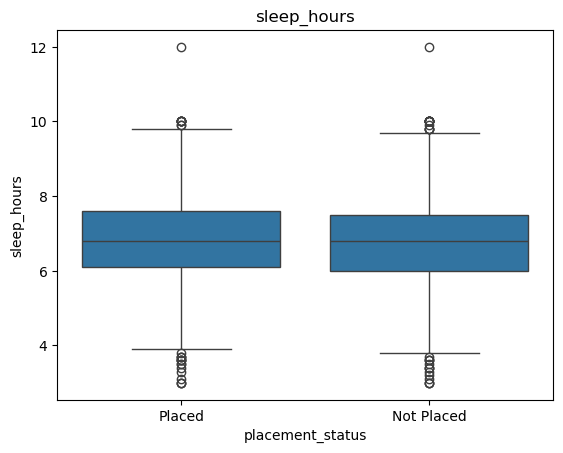

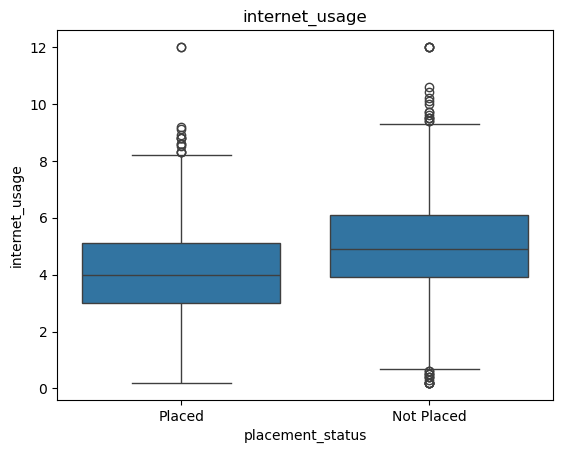

In [17]:
# Quick look at the cleaned categories
# Box plots: compare Placed and Not Placed for each number column
num_col = ['study_hours', 'sleep_hours', 'internet_usage']

for col in num_col:
    sns.boxplot(x="placement_status", y=col, data=df_copy)
    plt.title(col)
    plt.show()

Cleaning is done. Values are now consistent and there are no impossible numbers.
The missing values are still there. We fix them next.

---
## Step 4: Preprocessing

A decision tree needs clean numbers. Preprocessing has 4 small jobs:

1. **Separate X and y.** `X` = the inputs, `y` = the answer we want to predict.
2. **Split into train and test (80% / 20%).**
   *Real-life example:* Students learn from practice papers (train data) and the final exam (test data) has questions they have never seen. The test data tells us the truth.
3. **Convert text to numbers (one-hot encoding).**
   The column `branch` becomes separate columns like `branch_CSE = 1 or 0`, `branch_IT = 1 or 0`, and so on.

**Do we need scaling?** No. Decision trees ask questions like "attendance above 75?", so the scale of the numbers does not matter.

In [ ]:
# 1. Convert text to numbers (one-hot encoding) on branch and others label encoding.
from sklearn.preprocessing import LabelEncoder

# Create a copy
df_copy = df_copy.copy()

# Branch → One-Hot Encoding
df_copy = pd.get_dummies(
    df_copy,
    columns=["branch"],
    dtype=int,
    
)

# Label Encoding
label_en = LabelEncoder()

df_copy["gender"] = label_en.fit_transform(df_copy["gender"])
df_copy["extracurricular"] = label_en.fit_transform(df_copy["extracurricular"])
df_copy["placement_status"] = label_en.fit_transform(df_copy["placement_status"])

df_copy.head()

,gender,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,extracurricular,exam_score,placement_status,branch_CIVIL,branch_COMMERCE,branch_CSE,branch_ECE,branch_IT,branch_MECHANICAL
0,0,1.5,68.2,6.7,2.6,15.0,63.6,1,60.8,1,0,0,0,0,0,1
1,1,5.0,80.9,5.5,6.2,12.0,55.4,0,58.8,0,0,0,0,0,0,1
4,1,0.0,46.8,7.4,5.6,4.0,49.7,1,41.6,0,0,0,0,0,1,0
5,1,2.9,68.4,6.9,6.7,8.0,54.0,0,46.4,0,0,0,0,0,1,0
6,0,5.0,82.0,5.0,5.0,11.0,56.4,1,58.0,1,0,0,0,0,0,1


In [19]:
# 2. Separate X and y.
X = df_copy.drop(columns = ['placement_status'])
y = df_copy['placement_status']


In [20]:
# 3. Split into train and test (80% / 20%).
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(6511, 15)
(1628, 15)
(6511,)
(1628,)


---
## Step 5: Model
**Model : Default decision tree.**


In [21]:
from sklearn.tree import DecisionTreeClassifier
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [22]:
y_pred = clf.predict(X_test)

compare = pd.DataFrame({
    'Actul' : y_test,
    'Predicted' : y_pred
})
compare.head(10)


,Actul,Predicted
943,1,1
5035,1,1
1409,1,1
1023,1,0
1413,0,0
9910,0,0
5100,0,1
7405,1,0
3596,1,1
5888,0,1


In [ ]:
from sklearn.metrics import accuracy_score
Test_acc = accuracy_score(y_test, clf.predict(X_test))
Train_acc = accuracy_score(y_train, clf.predict(X_train))
print(f'Train accuracy: {Train_acc}')
print(f'Test accuracy: {Test_acc}')

Train accuracy: 1.0
Test accuracy: 0.7426289926289926


---
## Step 6: Tune

Tuning means finding the best **settings** (hyperparameters) for the tree.

| Setting | Meaning | Real-life idea |
|---|---|---|
| `max_depth` | Maximum number of question levels | Limit an interview to 3 rounds |
| `min_samples_leaf` | Minimum students allowed in a final group | Do not make a rule from just 2 students |
| `criterion` | How to measure "messy" groups: `gini` or `entropy` | Two different rulers for the same job |

We train trees with depth 1, 2, 3 ... 15 and plot train vs test accuracy.

In [24]:
# 4. Define hyperparameters
param_grid = {
    'max_depth':[3,5,7,10],
    'min_samples_leaf':[1,2,5,10],
    'criterion':['gini','entropy']
}

In [25]:
# RandomizedSearch / gridSearchCV
from sklearn.model_selection import RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator = clf,
    param_distributions = param_grid,
    n_iter = 10,
    cv = 5,
    scoring = 'accuracy',
    random_state = 42
)

In [26]:
# Train
random_search.fit(X_train, y_train)

,estimator,DecisionTreeC...ndom_state=42)
,param_distributions,"{'criterion': ['gini', 'entropy'], 'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 2, ...]}"
,n_iter,10
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [27]:
# Best parameters
print(random_search.best_params_)

{'min_samples_leaf': 2, 'max_depth': 7, 'criterion': 'entropy'}


In [28]:
# Best Model
best_model = random_search.best_estimator_

In [29]:
# prediction
y_pred = best_model.predict(X_test)

In [30]:
# final accuracy score
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test, y_pred))

0.8151105651105651


In [31]:
# Calculate and print train/test accuracy for the tuned (best) model
tuned_train_acc = accuracy_score(y_train, best_model.predict(X_train))
tuned_test_acc = accuracy_score(y_test, best_model.predict(X_test))

print(f'Tuned Model - Train Accuracy: {tuned_train_acc:.4f}')
print(f'Tuned Model - Test Accuracy: {tuned_test_acc:.4f}')

Tuned Model - Train Accuracy: 0.8352
Tuned Model - Test Accuracy: 0.8151


---
## Step 7: Evaluate

Now we test the tuned model on the **test data**, which it has never seen.

**Metrics in simple words** (think of "Placed" as the positive class):

| Metric | Question it answers |
|---|---|
| Accuracy | Out of all students, how many did we predict correctly? |
| Precision | Out of students we said "Placed", how many were really placed? |
| Recall | Out of students who were really placed, how many did we find? |
| F1-score | One number that balances precision and recall |


**Confusion matrix** is a 2x2 table that shows correct and wrong predictions of each type.

In [32]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
print(f'Accuracy : {accuracy_score(y_test, y_pred)  }')
print(f'Precision : {precision_score(y_test, y_pred)  }')
print(f'Recall : {recall_score(y_test, y_pred)  }')
print(f'F1-score : {f1_score(y_test, y_pred)  }')
print(f'Confusion matrix : \n{confusion_matrix(y_test, y_pred)  }')

Accuracy : 0.8151105651105651
Precision : 0.8382352941176471
Recall : 0.7769516728624535
F1-score : 0.8064308681672026
Confusion matrix : 
[[700 121]
 [180 627]]


---
## Step 8: Explain

A big reason to use a decision tree is that we can **explain** its decisions.
A placement officer will not trust a model that only says "Placed" without a reason.

### Feature importance

C:\Users\laxit\AppData\Local\Temp\ipykernel_15092\2958553386.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


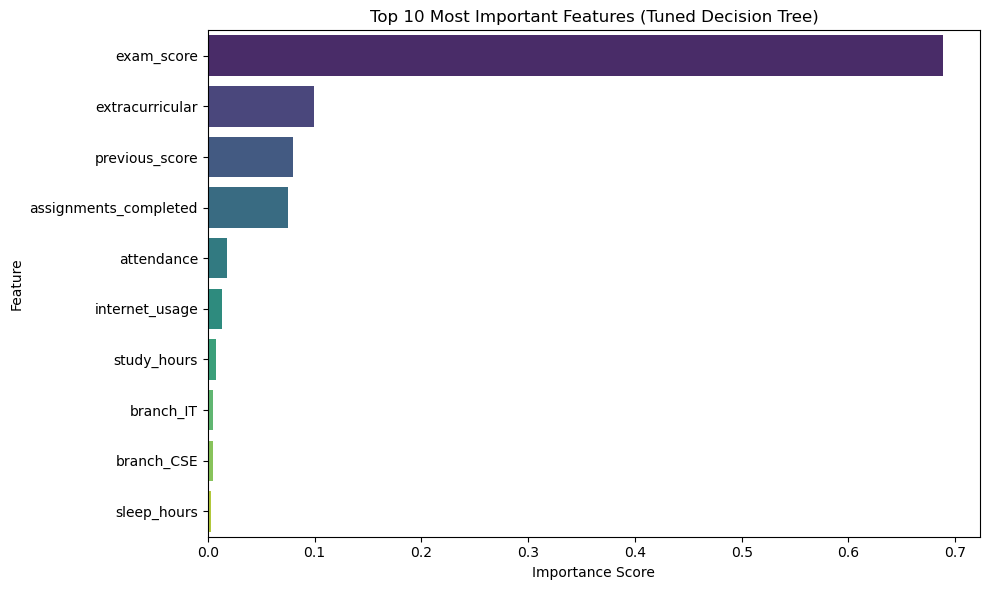

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Get feature importances from our best model
importances = best_model.feature_importances_
features = X.columns

# Create a DataFrame for easy sorting and plotting
feature_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot the top 10 most important features
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance_df.head(10),
    palette='viridis'
)
plt.title('Top 10 Most Important Features (Tuned Decision Tree)')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## Step 9: Save model


In [34]:
import joblib

# Save the trained best model to a file
model_filename = 'placement_model.joblib'
joblib.dump(best_model, model_filename)

print(f"Model successfully saved as '{model_filename}'!")

Model successfully saved as 'placement_model.joblib'!


In [35]:
import joblib
joblib.dump(X.columns.tolist(), 'columns.joblib')
print("✅ columns.joblib saved!")

✅ columns.joblib saved!


**Next: build the FastAPI app**
- `POST /predict` takes student details and returns Placed / Not Placed with the probability.
- A simple web page (HTML form) calls this API and shows the result.
- Keep `placement_model.joblib` and the same scikit-learn version in the API project.

#